In [88]:
pip install pycuda

In [89]:
import numpy as np
import sys
import math
import time
import pycuda.autoinit
import pycuda.driver as drv
from pycuda.compiler import SourceModule
import cv2
from matplotlib import pyplot as plt
from google.colab import files

In [90]:
print("Загрузите изображение (BMP):")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
print(f"Загружен файл: {file_name}")
image = cv2.imread(file_name)
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

N, M = image.shape[0], image.shape[1]
sigma_r, sigma_d = 500, 500
block_size=(16,16,1)
grid_size=(N//block_size[0] + 1, M//block_size[1] + 1)

Загрузите изображение (BMP):


Saving file.bmp to file (5).bmp
Загружен файл: file (5).bmp


In [91]:
kernel = SourceModule(
    """
    __global__ void bilateral_filter_GPU(
    unsigned char* image, unsigned char* image_after_filtr,
    int N, int M,   // N - height  M - width
    float sigma_d, float sigma_r)
{
    int row = threadIdx.x + blockDim.x * blockIdx.x;
    int col = threadIdx.y + blockDim.y * blockIdx.y;

    if (row < N && col < M) {
        float h = 0, k = 0;
        unsigned char f0 = image[row * M + col];

        for (int dr = -1; dr <= 1; dr++) {
            for (int dc = -1; dc <= 1; dc++) {
                int nr = min(max(row + dr, 0), N - 1);
                int nc = min(max(col + dc, 0), M - 1);

                unsigned char fi = image[nr * M + nc];

                float g = exp(-(float)(dr*dr + dc*dc) / (sigma_d * sigma_d));
                float r = exp(-(float)((fi-f0)*(fi-f0)) / (sigma_r * sigma_r));

                float w = g * r;
                k += w;
                h += w * fi;
            }
        }
        image_after_filtr[row * M + col] = (unsigned char)(h / k);
    }
}
    """
)

In [92]:
filtered_image_gpu = np.zeros((N, M), dtype=np.uint8)
bilateralFilterGPU = kernel.get_function("bilateral_filter_GPU")

start_time_gpu = time.time()

bilateralFilterGPU(
    drv.In(image),
    drv.Out(filtered_image_gpu),
    np.int32(N), np.int32(M),
    np.float32(sigma_d), np.float32(sigma_r),
    block=block_size,
    grid=grid_size
)

drv.Context.synchronize()
end_time_gpu = time.time() - start_time_gpu

print(f"Time bilateral filter GPU: {end_time_gpu} sec.")

Time bilateral filter GPU: 0.0020911693572998047 sec.


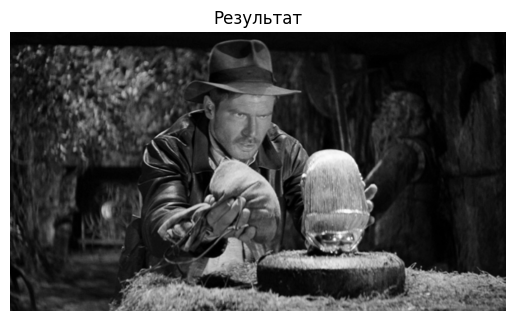

In [93]:
plt.imshow(filtered_image_gpu, cmap='gray')
plt.title('Результат')
plt.axis('off')
plt.show()

In [94]:


def bilateralFilterCPU(image, diameter, sigma_r, sigma_d):
  image_after_filtr = np.zeros(image.shape)
  radius = diameter//2
  for i in range(1, len(image)-1):
    for j in range(1, len(image[0])-1):
      h = 0
      k = 0
      for ik in range(i-radius, i+radius+1):
        for jk in range(j-radius, j+radius+1):
          x = ik - i
          y = jk - j
          w = math.exp(-((x**2+y**2)/(sigma_d**2))) * math.exp(((int(image[ik][jk])-int(image[i][j]))**2)/(sigma_r**2))
          h += image[ik][jk]*w
          k += w
      image_after_filtr[i][j] = h/k
  return image_after_filtr



In [97]:
from numba import njit

@njit
def bilateralFilterCPU(image, sigma_d, sigma_r):
    N, M = image.shape
    image_after_filtr = np.zeros((N, M), dtype=np.uint8)

    for row in range(N):
        for col in range(M):
            h = 0.0
            k = 0.0
            f0 = int(image[row, col])

            for dr in range(-1, 2):
                for dc in range(-1, 2):
                    nr = min(max(row + dr, 0), N - 1)
                    nc = min(max(col + dc, 0), M - 1)

                    fi = int(image[nr, nc])

                    g = math.exp(-(dr*dr + dc*dc) / (sigma_d * sigma_d))
                    r = math.exp(-((fi - f0)**2) / (sigma_r * sigma_r))

                    w = g * r
                    k += w
                    h += w * fi

            image_after_filtr[row, col] = int(h / k)

    return image_after_filtr


start_time_cpu = time.time()
filtered_image_cpu = bilateralFilterCPU(image, sigma_d, sigma_r)
end_time_cpu = time.time() - start_time_cpu

print(f"Time CPU bilateral filter: {end_time_cpu} sec.")

Time CPU bilateral filter: 0.30717992782592773 sec.


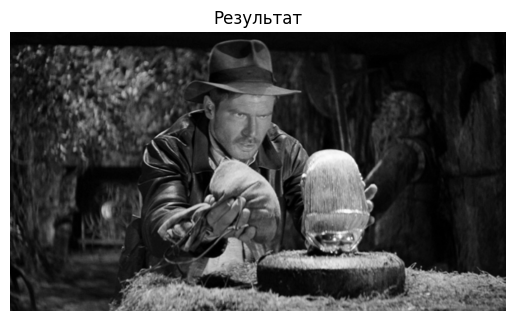

In [98]:
plt.imshow(filtered_image_cpu, cmap='gray')
plt.title('Результат')
plt.axis('off')
plt.show()